# prepration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('Traffic Monitoring Data.csv')
df

,time_from,time_to,countline_id,name,car,bus,cyclist,motorbike,pedestrian,rigid,time_bucket,day,total_count
0,2024-01-01 00:00:00+00,2024-01-02 00:00:00+00,52455,Padestrian Path,0,0,0,0,0,0,5min,0,0
1,2024-01-01 00:00:00+00,2024-01-02 00:00:00+00,52454,Inbound_Traffic,0,0,0,0,0,0,5min,0,0
2,2024-01-01 00:00:00+00,2024-01-02 00:00:00+00,52453,Outbound_Traffic,0,0,0,0,0,0,5min,0,0
3,2024-01-01 00:00:00+00,2024-01-01 01:00:00+00,52455,Padestrian Path,0,0,0,0,0,0,5min,0,0
4,2024-01-01 00:00:00+00,2024-01-01 01:00:00+00,52454,Inbound_Traffic,0,0,0,0,0,0,5min,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48418,2025-10-07 14:00:00+00,2025-10-07 15:00:00+00,52454,Inbound_Traffic,81,3,19,0,14,0,5min,1,117
48419,2025-10-07 14:00:00+00,2025-10-07 15:00:00+00,52455,Padestrian Path,0,0,4,0,544,0,5min,1,548
48420,2025-10-07 15:00:00+00,2025-10-07 16:00:00+00,52455,Padestrian Path,0,0,8,0,607,0,5min,1,615
48421,2025-10-07 15:00:00+00,2025-10-07 16:00:00+00,52453,Outbound_Traffic,312,1,20,1,7,0,5min,1,341


In [4]:
df.describe()

,countline_id,car,bus,cyclist,motorbike,pedestrian,rigid,day,total_count
count,48423.000000,48423.000000,48423.000000,48423.000000,48423.000000,48423.000000,48423.000000,48423.000000,48423.000000
mean,52454.000000,35.759722,1.162588,3.534477,0.170208,35.945563,0.112674,2.993371,76.685232
std,0.816505,171.017073,5.244686,26.464196,0.814899,274.448778,0.801949,2.001945,339.725924
min,52453.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,52453.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,52454.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000
75%,52455.000000,6.000000,1.000000,2.000000,0.000000,2.000000,0.000000,5.000000,37.000000
max,52455.000000,2874.000000,130.000000,2347.000000,16.000000,7671.000000,55.000000,6.000000,7781.000000


In [5]:
df.columns

Index(['time_from', 'time_to', 'countline_id', 'name', 'car', 'bus', 'cyclist',
       'motorbike', 'pedestrian', 'rigid', 'time_bucket', 'day',
       'total_count'],
      dtype='object')

In [6]:
df.shape

(48423, 13)

In [7]:
df['countline_id'].unique()


array([52455, 52454, 52453])

In [8]:
df['name'].unique()

array(['Padestrian Path', 'Inbound_Traffic', 'Outbound_Traffic'],
      dtype=object)

In [9]:
df['time_from'].dtype

dtype('O')

In [10]:
# This isn't very useful to do numerical operations, and is best left as an object
df['countline_id'] = df['countline_id'].astype('object')
display(df['countline_id'].dtype)

dtype('O')

In [11]:
#Group countline_ids together, could do the same with 'name' col
df1 = df.groupby('countline_id')
df1

# Get data

In [12]:
#Convert time_from and time_to to datetime types for easier manipulation
cols = ['time_from', 'time_to']
for col in cols:
    df[col] = pd.to_datetime(df[col])



In [13]:
#Add Monthly, daily, and hourly columns
df['month'] = df['time_from'].dt.to_period('M')
df['daily'] = df['time_from'].dt.to_period('D')
df['hour'] = df['time_from'].dt.to_period('h')

/tmp/ipython-input-3377670623.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['time_from'].dt.to_period('M')
/tmp/ipython-input-3377670623.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['daily'] = df['time_from'].dt.to_period('D')
/tmp/ipython-input-3377670623.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['hour'] = df['time_from'].dt.to_period('h')


In [14]:
# Get unique sensor IDs
sensors = df['countline_id'].unique()

# Create a dictionary to store each sensor's data
sensor_data = []

# Loop through each sensor ID and extract its rows
for sensor_id in sensors:
    #sensor_data[sensor_id] = df[df['countline_id'] == sensor_id].copy()
    sensor_data.append(df[df['countline_id'] == sensor_id].copy())


# s1 = sensor_data[52455]
# display(s1.head())

In [15]:
# sensors = df['countline_id'].unique()
# sensor_data = []

In [16]:
sensor_data = [ df[df['countline_id'] == sensor_id].copy() for sensor_id in sensors]
display(sensor_data)

[                      time_from                   time_to countline_id  \
 0     2024-01-01 00:00:00+00:00 2024-01-02 00:00:00+00:00        52455   
 3     2024-01-01 00:00:00+00:00 2024-01-01 01:00:00+00:00        52455   
 6     2024-01-01 01:00:00+00:00 2024-01-01 02:00:00+00:00        52455   
 9     2024-01-01 02:00:00+00:00 2024-01-01 03:00:00+00:00        52455   
 12    2024-01-01 03:00:00+00:00 2024-01-01 04:00:00+00:00        52455   
 ...                         ...                       ...          ...   
 48410 2025-10-07 11:00:00+00:00 2025-10-07 12:00:00+00:00        52455   
 48413 2025-10-07 12:00:00+00:00 2025-10-07 13:00:00+00:00        52455   
 48416 2025-10-07 13:00:00+00:00 2025-10-07 14:00:00+00:00        52455   
 48419 2025-10-07 14:00:00+00:00 2025-10-07 15:00:00+00:00        52455   
 48420 2025-10-07 15:00:00+00:00 2025-10-07 16:00:00+00:00        52455   
 
                   name  car  bus  cyclist  motorbike  pedestrian  rigid  \
 0      Padestrian Pat

In [17]:
#.values converts into numpy array
# s1, s2,s3 = sensor_data
pedestrian, inbound, outbound = sensor_data
print(pedestrian.shape, inbound.shape, outbound.shape)

(16141, 16) (16141, 16) (16141, 16)


In [18]:
# s1, s2,s3 = sensor_data


# Sensor data



In [19]:
pedestrian

,time_from,time_to,countline_id,name,car,bus,cyclist,motorbike,pedestrian,rigid,time_bucket,day,total_count,month,daily,hour
0,2024-01-01 00:00:00+00:00,2024-01-02 00:00:00+00:00,52455,Padestrian Path,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 00:00
3,2024-01-01 00:00:00+00:00,2024-01-01 01:00:00+00:00,52455,Padestrian Path,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 00:00
6,2024-01-01 01:00:00+00:00,2024-01-01 02:00:00+00:00,52455,Padestrian Path,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 01:00
9,2024-01-01 02:00:00+00:00,2024-01-01 03:00:00+00:00,52455,Padestrian Path,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 02:00
12,2024-01-01 03:00:00+00:00,2024-01-01 04:00:00+00:00,52455,Padestrian Path,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48410,2025-10-07 11:00:00+00:00,2025-10-07 12:00:00+00:00,52455,Padestrian Path,0,0,0,0,745,2,5min,1,747,2025-10,2025-10-07,2025-10-07 11:00
48413,2025-10-07 12:00:00+00:00,2025-10-07 13:00:00+00:00,52455,Padestrian Path,0,0,4,1,891,0,5min,1,896,2025-10,2025-10-07,2025-10-07 12:00
48416,2025-10-07 13:00:00+00:00,2025-10-07 14:00:00+00:00,52455,Padestrian Path,2,0,5,1,547,0,5min,1,555,2025-10,2025-10-07,2025-10-07 13:00
48419,2025-10-07 14:00:00+00:00,2025-10-07 15:00:00+00:00,52455,Padestrian Path,0,0,4,0,544,0,5min,1,548,2025-10,2025-10-07,2025-10-07 14:00


In [20]:
inbound

,time_from,time_to,countline_id,name,car,bus,cyclist,motorbike,pedestrian,rigid,time_bucket,day,total_count,month,daily,hour
1,2024-01-01 00:00:00+00:00,2024-01-02 00:00:00+00:00,52454,Inbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 00:00
4,2024-01-01 00:00:00+00:00,2024-01-01 01:00:00+00:00,52454,Inbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 00:00
7,2024-01-01 01:00:00+00:00,2024-01-01 02:00:00+00:00,52454,Inbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 01:00
10,2024-01-01 02:00:00+00:00,2024-01-01 03:00:00+00:00,52454,Inbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 02:00
13,2024-01-01 03:00:00+00:00,2024-01-01 04:00:00+00:00,52454,Inbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48409,2025-10-07 11:00:00+00:00,2025-10-07 12:00:00+00:00,52454,Inbound_Traffic,157,2,7,1,15,0,5min,1,182,2025-10,2025-10-07,2025-10-07 11:00
48412,2025-10-07 12:00:00+00:00,2025-10-07 13:00:00+00:00,52454,Inbound_Traffic,111,2,8,0,18,0,5min,1,139,2025-10,2025-10-07,2025-10-07 12:00
48415,2025-10-07 13:00:00+00:00,2025-10-07 14:00:00+00:00,52454,Inbound_Traffic,118,2,6,3,14,0,5min,1,143,2025-10,2025-10-07,2025-10-07 13:00
48418,2025-10-07 14:00:00+00:00,2025-10-07 15:00:00+00:00,52454,Inbound_Traffic,81,3,19,0,14,0,5min,1,117,2025-10,2025-10-07,2025-10-07 14:00


In [21]:
outbound

,time_from,time_to,countline_id,name,car,bus,cyclist,motorbike,pedestrian,rigid,time_bucket,day,total_count,month,daily,hour
2,2024-01-01 00:00:00+00:00,2024-01-02 00:00:00+00:00,52453,Outbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 00:00
5,2024-01-01 00:00:00+00:00,2024-01-01 01:00:00+00:00,52453,Outbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 00:00
8,2024-01-01 01:00:00+00:00,2024-01-01 02:00:00+00:00,52453,Outbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 01:00
11,2024-01-01 02:00:00+00:00,2024-01-01 03:00:00+00:00,52453,Outbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 02:00
14,2024-01-01 03:00:00+00:00,2024-01-01 04:00:00+00:00,52453,Outbound_Traffic,0,0,0,0,0,0,5min,0,0,2024-01,2024-01-01,2024-01-01 03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48408,2025-10-07 11:00:00+00:00,2025-10-07 12:00:00+00:00,52453,Outbound_Traffic,171,1,4,1,3,0,5min,1,180,2025-10,2025-10-07,2025-10-07 11:00
48411,2025-10-07 12:00:00+00:00,2025-10-07 13:00:00+00:00,52453,Outbound_Traffic,172,1,6,2,9,0,5min,1,190,2025-10,2025-10-07,2025-10-07 12:00
48414,2025-10-07 13:00:00+00:00,2025-10-07 14:00:00+00:00,52453,Outbound_Traffic,252,1,2,1,7,0,5min,1,263,2025-10,2025-10-07,2025-10-07 13:00
48417,2025-10-07 14:00:00+00:00,2025-10-07 15:00:00+00:00,52453,Outbound_Traffic,201,2,6,1,10,0,5min,1,220,2025-10,2025-10-07,2025-10-07 14:00


## Data according to Dates

In [22]:
# data = df['time_from'].dt.to_period('M')
# df_new = pd.DataFrame(data)
# df_new = df.groupby('time_from')['total_count'].sum()
# df_new = df_new.reset_index()
# # df_new.shape
# Step 1: convert datetime to month
# pedestrian['month'] = pedestrian['time_from'].dt.to_period('M')
# pedestrian['daily'] = pedestrian['time_from'].dt.to_period('D')
# Step 1: convert datetime to month
# inbound['month'] = inbound['time_from'].dt.to_period('M')
# Step 1: convert datetime to month
# outbound['month'] = outbound['time_from'].dt.to_period('M')
# Step 1: convert datetime to month
# monthly_traffic = s1
# cols = ['car', 'bus', 'cyclist', 'motorbike', 'pedestrian', 'rigid', 'total_count']
# monthly_traffic['month'] = monthly_traffic['time_from'].dt.to_period('M')
# monthly_traffic = monthly_traffic.groupby('month')[cols].sum().reset_index()

# print(monthly_traffic)
# print(monthly_traffic.shape)  # rows = number of months, columns = 2

# numeric_cols = s1.iloc[:, 3:-1].columns  # get column names from position 3 to second-to-last

## Roads - monthly, daily, hourly

In [23]:
df.columns

Index(['time_from', 'time_to', 'countline_id', 'name', 'car', 'bus', 'cyclist',
       'motorbike', 'pedestrian', 'rigid', 'time_bucket', 'day', 'total_count',
       'month', 'daily', 'hour'],
      dtype='object')

In [24]:
# df_month = pd.DataFrame(df[['time_from', 'name', 'car', 'bus', 'cyclist','motorbike','pedestrian', 'rigid', 'total_count', 'month', 'daily', 'hour']])
# df_monthly = pd.DataFrame()

In [25]:
# df_pedestrian_monthtly = df[df['name'] == 'Padestrian Path']
# df_pedestrian_monthtly = df_pedestrian_monthtly.groupby('month')[cols].sum().reset_index()

In [26]:
# df_monthly['name'].unique()

In [27]:
# Columns to sum
cols_to_sum = ['car', 'bus', 'cyclist', 'motorbike', 'pedestrian', 'rigid', 'total_count']

# Monthly aggregation
df_monthly = df.groupby([df['time_from'].dt.to_period('M'), 'name', 'countline_id'])[cols_to_sum].sum().reset_index()

# Daily aggregation
df_daily = df.groupby([df['time_from'].dt.to_period('D'), 'name', 'countline_id'])[cols_to_sum].sum().reset_index()

# Daily aggregation
df_hourly = df.groupby([df['time_from'].dt.to_period('H'), 'name', 'countline_id'])[cols_to_sum].sum().reset_index()



/tmp/ipython-input-3630676668.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_monthly = df.groupby([df['time_from'].dt.to_period('M'), 'name', 'countline_id'])[cols_to_sum].sum().reset_index()
/tmp/ipython-input-3630676668.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_daily = df.groupby([df['time_from'].dt.to_period('D'), 'name', 'countline_id'])[cols_to_sum].sum().reset_index()
/tmp/ipython-input-3630676668.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_hourly = df.groupby([df['time_from'].dt.to_period('H'), 'name', 'countline_id'])[cols_to_sum].sum().reset_index()
/tmp/ipython-input-3630676668.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.groupby([df['time_from'].dt.to_period('H'), 'name', 'countline_id'])[cols_to_sum].sum().reset_index()


In [28]:
df_monthly

,time_from,name,countline_id,car,bus,cyclist,motorbike,pedestrian,rigid,total_count
0,2024-01,Inbound_Traffic,52454,0,0,0,0,0,0,0
1,2024-01,Outbound_Traffic,52453,0,0,0,0,0,0,0
2,2024-01,Padestrian Path,52455,0,0,0,0,0,0,0
3,2024-02,Inbound_Traffic,52454,0,0,0,0,0,0,0
4,2024-02,Outbound_Traffic,52453,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
61,2025-09,Outbound_Traffic,52453,86158,1194,2288,256,4036,46,93978
62,2025-09,Padestrian Path,52455,976,24,3894,184,232346,96,237520
63,2025-10,Inbound_Traffic,52454,21859,667,1355,106,1600,79,25666
64,2025-10,Outbound_Traffic,52453,21672,241,467,60,792,13,23245


In [29]:
# rows == 'Pedestrian Path'
df_monthly[df_monthly['name'] == 'Padestrian Path']

# Traffic starts after 2024-09
#vafter expereimenting this is the samed for other roads

,time_from,name,countline_id,car,bus,cyclist,motorbike,pedestrian,rigid,total_count
2,2024-01,Padestrian Path,52455,0,0,0,0,0,0,0
5,2024-02,Padestrian Path,52455,0,0,0,0,0,0,0
8,2024-03,Padestrian Path,52455,0,0,0,0,0,0,0
11,2024-04,Padestrian Path,52455,0,0,0,0,0,0,0
14,2024-05,Padestrian Path,52455,0,0,0,0,0,0,0
17,2024-06,Padestrian Path,52455,0,0,0,0,0,0,0
20,2024-07,Padestrian Path,52455,0,0,0,0,0,0,0
23,2024-08,Padestrian Path,52455,0,0,0,0,0,0,0
26,2024-09,Padestrian Path,52455,0,0,0,0,0,0,0
29,2024-10,Padestrian Path,52455,530,66,4240,164,147222,44,152266


In [30]:
# # Step 2: group by month and sum total_count
# cols = [ 'car', 'bus', 'cyclist', 'motorbike', 'rigid', 'total_count']
# df_monthly = df.groupby('month')[cols].sum().reset_index()
# # df_pedestrian_monthtly = df_pedestrian_monthtly.groupby('month')[cols].sum().reset_index()
# df_pedestrian_daily = pedestrian.groupby('daily')[cols].sum().reset_index()
# df_pedestrian_hourly = pedestrian.groupby('hour')[cols].sum().reset_index()

# print(df_monthly)
# print(df_monthly.shape)  # rows = number of months, columns = 2

# # numeric_cols = s1.iloc[:, 3:-1].columns  # get column names from position 3 to second-to-last

In [31]:
df_monthly.columns

Index(['time_from', 'name', 'countline_id', 'car', 'bus', 'cyclist',
       'motorbike', 'pedestrian', 'rigid', 'total_count'],
      dtype='object')

In [32]:
df_daily[(df_daily['time_from'] >= '2024-10') &  (df_daily['time_from'] <= '2024-11') & (df_daily['name'] == 'Padestrian Path')]
# df_daily[(df_daily['time_from'] >= '2024-10') &  (df_daily['time_from'] <= '2024-11') & (df_daily['name'] == 'Inbound_Traffic')]
# df_daily[(df_daily['time_from'] >= '2024-10') &  (df_daily['time_from'] <= '2024-11') & (df_daily['name'] == 'Outbound_Traffic')]

#Traffic first occurs on 2024-10-11

,time_from,name,countline_id,car,bus,cyclist,motorbike,pedestrian,rigid,total_count
824,2024-10-01,Padestrian Path,52455,0,0,0,0,0,0,0
827,2024-10-02,Padestrian Path,52455,0,0,0,0,0,0,0
830,2024-10-03,Padestrian Path,52455,0,0,0,0,0,0,0
833,2024-10-04,Padestrian Path,52455,0,0,0,0,0,0,0
836,2024-10-05,Padestrian Path,52455,0,0,0,0,0,0,0
839,2024-10-06,Padestrian Path,52455,0,0,0,0,0,0,0
842,2024-10-07,Padestrian Path,52455,0,0,0,0,0,0,0
845,2024-10-08,Padestrian Path,52455,0,0,0,0,0,0,0
848,2024-10-09,Padestrian Path,52455,0,0,0,0,0,0,0
851,2024-10-10,Padestrian Path,52455,0,0,0,0,0,0,0


In [33]:
# testing for the exact hour road was opened

df_hourly[(df_hourly['time_from'] >= '2024-10-10') &  (df_hourly['total_count'] != 0)]
# df_hourly[(df_hourly['time_from'] >= '2024-10-10') &  (df_hourly['time_from'] <= '2024-10-12')]

# very first time used -> 2024-10-11 00:00, but not used again until 	2024-10-11 15:00	0	0	1	0	65	0	66


,time_from,name,countline_id,car,bus,cyclist,motorbike,pedestrian,rigid,total_count
20448,2024-10-11 00:00,Inbound_Traffic,52454,146,18,7,1,12,0,184
20449,2024-10-11 00:00,Outbound_Traffic,52453,391,19,21,1,17,0,449
20450,2024-10-11 00:00,Padestrian Path,52455,7,0,66,0,538,0,611
20493,2024-10-11 15:00,Inbound_Traffic,52454,4,0,0,0,0,0,4
20494,2024-10-11 15:00,Outbound_Traffic,52453,18,0,0,0,0,0,18
...,...,...,...,...,...,...,...,...,...,...
46483,2025-10-07 14:00,Outbound_Traffic,52453,201,2,6,1,10,0,220
46484,2025-10-07 14:00,Padestrian Path,52455,0,0,4,0,544,0,548
46485,2025-10-07 15:00,Inbound_Traffic,52454,70,4,10,0,4,0,88
46486,2025-10-07 15:00,Outbound_Traffic,52453,312,1,20,1,7,0,341


In [34]:
# Cutting off unneeded data -> cut off initial zeros
# df_pedestrian_monthtly = df_pedestrian_monthtly.iloc[9:, :]
df_monthly = df_monthly[df_monthly['time_from'] >= '2024-09']
df_daily = df_daily[df_daily['time_from'] >= '2024-10-11']
df_hourly = df_hourly[df_hourly['time_from'] >= '2024-10-11']


In [35]:
#sanity check to see if it worked
df_monthly

,time_from,name,countline_id,car,bus,cyclist,motorbike,pedestrian,rigid,total_count
24,2024-09,Inbound_Traffic,52454,0,0,0,0,0,0,0
25,2024-09,Outbound_Traffic,52453,0,0,0,0,0,0,0
26,2024-09,Padestrian Path,52455,0,0,0,0,0,0,0
27,2024-10,Inbound_Traffic,52454,61124,2128,3960,226,5806,562,73806
28,2024-10,Outbound_Traffic,52453,60924,1274,1478,232,2572,284,66764
29,2024-10,Padestrian Path,52455,530,66,4240,164,147222,44,152266
30,2024-11,Inbound_Traffic,52454,100700,3404,6766,312,5176,398,116756
31,2024-11,Outbound_Traffic,52453,101004,2126,2364,294,3530,212,109530
32,2024-11,Padestrian Path,52455,560,58,7582,220,241186,34,249640
33,2024-12,Inbound_Traffic,52454,59538,3038,3766,178,2442,214,69176


### Plotting Graphs

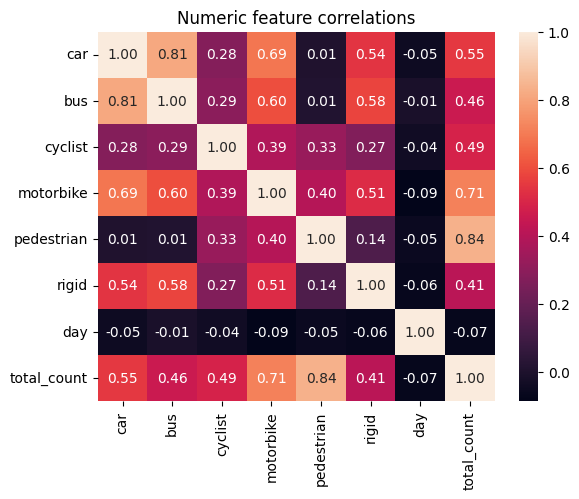

In [36]:
# correlation heatmap
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f")
plt.title("Numeric feature correlations")
plt.show()

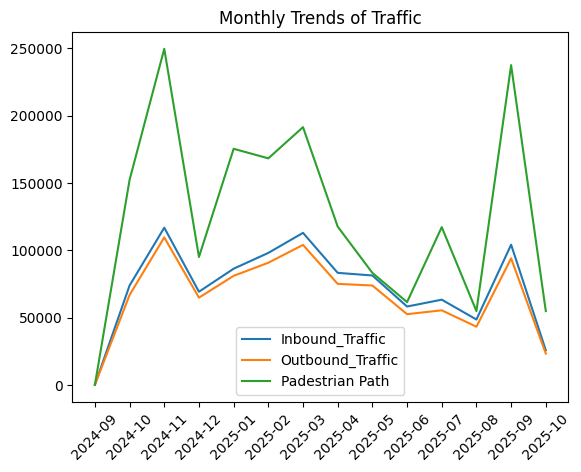

In [37]:
df['month'] = df['month'].astype(str)

for road in df_monthly['name'].unique():
    data = df_monthly[df_monthly['name'] == road]
    plt.plot(data['time_from'].astype(str), data['total_count'], label=road)
plt.title('Monthly Trends of Traffic')
plt.legend()
plt.xticks(rotation=45)
plt.show()



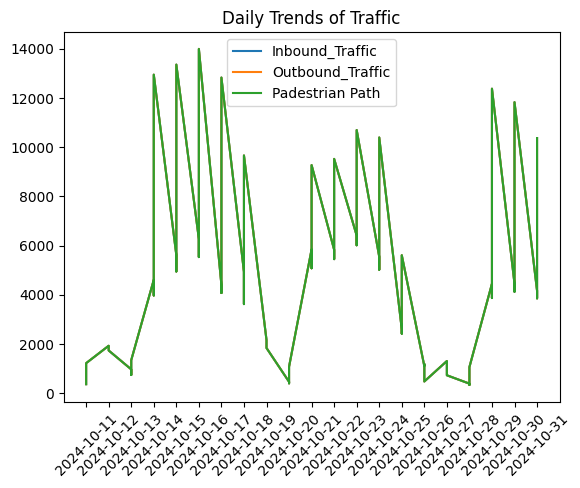

In [38]:
data_range = df_daily[(df_daily['time_from'] >= '2024-10-11') &  (df_daily['time_from'] <= '2024-10-31')]

for road in df_daily['name'].unique():
    # data = df_daily[df_daily['name'] == road]
    data = data_range
    plt.plot(data['time_from'].astype(str), data['total_count'], label=road)
plt.title('Daily Trends of Traffic')
plt.legend()
plt.xticks(rotation=45)
plt.show()



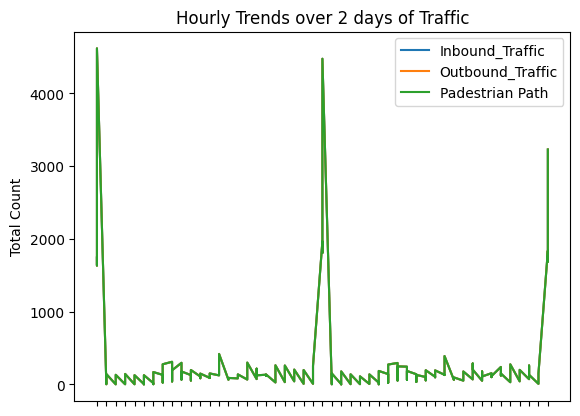

In [39]:
data_range = df_hourly[(df_hourly['time_from'] >= '2024-12-11 00:00') &  (df_hourly['time_from'] <= '2024-12-13 00:00')]

for road in df_hourly['name'].unique():
    # data = df_hourly[df_hourly['name'] == road]
    data = data_range
    plt.plot(data['time_from'].astype(str), data['total_count'], label=road)

plt.title('Hourly Trends over 2 days of Traffic')
plt.legend()
plt.ylabel('Total Count')
plt.gca().set_xticklabels([])
plt.show()


### box plots

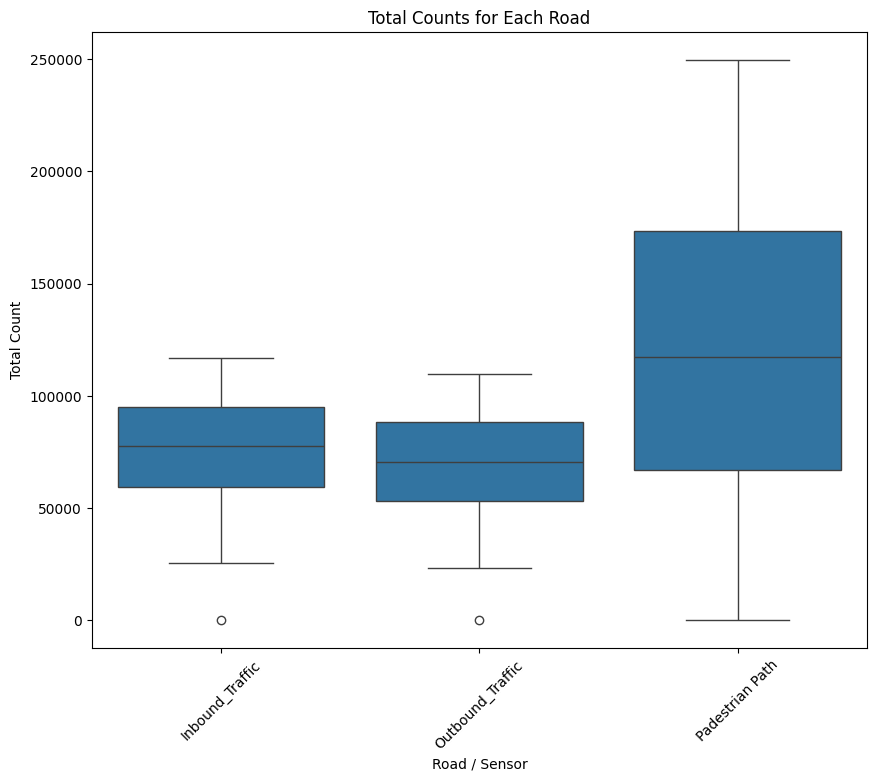

In [40]:

plt.figure(figsize=(10,8))
sns.boxplot(data=df_monthly, x='name', y='total_count')

plt.xticks(rotation=45)
plt.title("Total Counts for Each Road")
plt.xlabel("Road / Sensor")
plt.ylabel("Total Count")
plt.show()


In [41]:
df_monthly.shape

(42, 10)

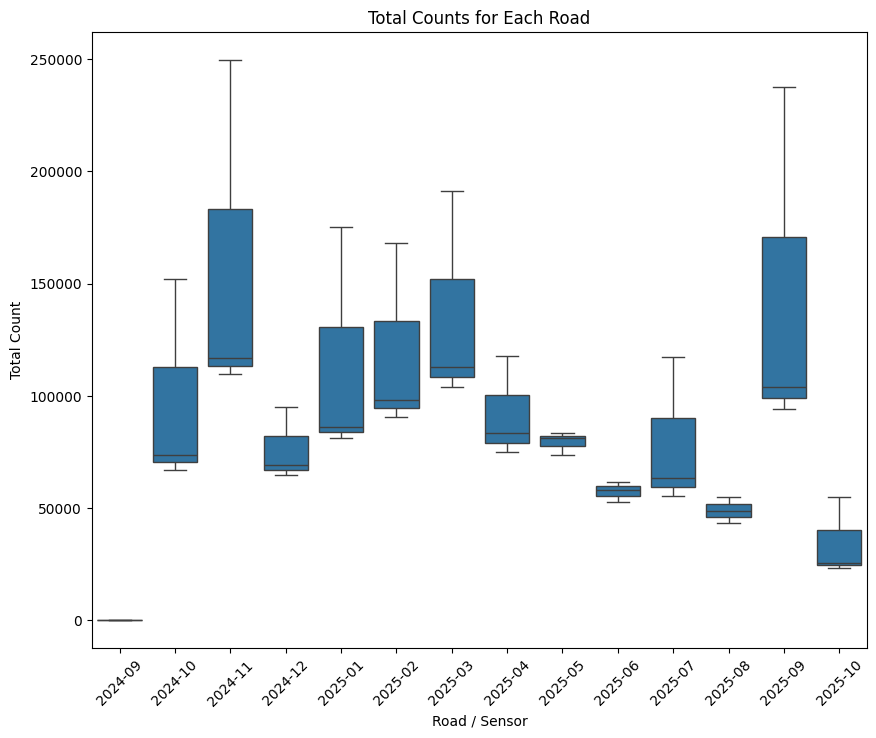

In [42]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df_monthly, x='time_from', y='total_count')

plt.xticks(rotation=45)
plt.title("Total Counts for Each Road")
plt.xlabel("Road / Sensor")
plt.ylabel("Total Count")
plt.show()


# Machine Learning

In [43]:
df.columns

Index(['time_from', 'time_to', 'countline_id', 'name', 'car', 'bus', 'cyclist',
       'motorbike', 'pedestrian', 'rigid', 'time_bucket', 'day', 'total_count',
       'month', 'daily', 'hour'],
      dtype='object')

## Classification

In [44]:
# df_monthly lacks the necessary sufficient data for classification without heavy bias or inaccurate on other datasets

# df_monthly['traffic_level'] = pd.qcut(df_monthly['total_count'], q=3, labels=['Low', 'Medium', 'High'])


# divide the df_daily into 3 distinct traffic level categories
df_daily = df_daily.copy() # Explicitly create a copy
df_daily['traffic_level'] = pd.qcut(df_daily['total_count'], q=3, labels=['Low', 'Medium', 'High'])

In [45]:
df_daily

,time_from,name,countline_id,car,bus,cyclist,motorbike,pedestrian,rigid,total_count,traffic_level
852,2024-10-11,Inbound_Traffic,52454,292,36,14,2,24,0,368,Low
853,2024-10-11,Outbound_Traffic,52453,782,38,42,2,34,0,898,Low
854,2024-10-11,Padestrian Path,52455,14,0,132,0,1076,0,1222,Low
855,2024-10-12,Inbound_Traffic,52454,1712,94,18,2,98,4,1928,Low
856,2024-10-12,Outbound_Traffic,52453,1700,74,22,0,70,4,1870,Low
...,...,...,...,...,...,...,...,...,...,...,...
1933,2025-10-06,Outbound_Traffic,52453,4274,32,108,14,150,2,4580,High
1934,2025-10-06,Padestrian Path,52455,34,6,168,18,11544,6,11776,High
1935,2025-10-07,Inbound_Traffic,52454,2065,29,145,12,146,7,2404,Medium
1936,2025-10-07,Outbound_Traffic,52453,1570,11,49,6,60,1,1697,Low


## Common features used across classification models

In [46]:
# df_monthly = df_monthly.copy()
# df_monthly['month_num'] = df_monthly['time_from'].dt.month

features = ['car', 'bus', 'cyclist', 'motorbike', 'rigid', 'pedestrian', 'total_count']
target = 'traffic_level'

print("Features:", features)
print("Target variable:", target)

Features: ['car', 'bus', 'cyclist', 'motorbike', 'rigid', 'pedestrian', 'total_count']
Target variable: traffic_level


In [47]:
# features and target
X = df_daily[features]
y = df_daily[target]

# encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


### Logistic regression

In [48]:
def plot_confusion_matrix(y_test, y_pred, le):
    # Plot confusion matrix for classification results
    cm = confusion_matrix(y_test, y_pred)
    # plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.xticks([0,1,2], le.classes_)
    plt.yticks([0,1,2], le.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
    plt.show()

In [49]:
def display_metric(y_test, y_pred):
  # metrics
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print("Precision:", precision_score(y_test, y_pred, average='weighted'))
  print("Recall:", recall_score(y_test, y_pred, average='weighted'))
  print("F1-score:", f1_score(y_test, y_pred, average='weighted'))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


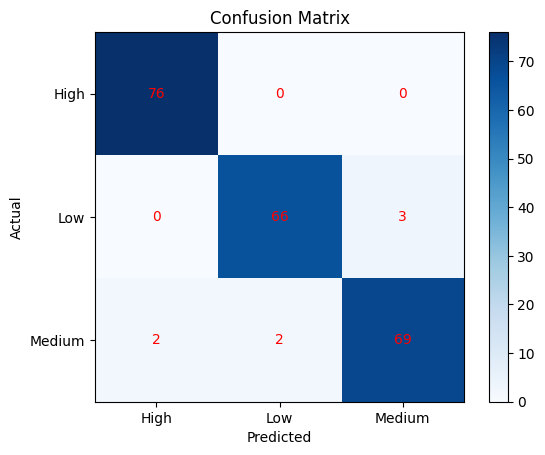

Accuracy: 0.9678899082568807
Precision: 0.9677990991738968
Recall: 0.9678899082568807
F1-score: 0.9677550500310552


In [50]:


# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ("scaler", StandardScaler()),  # scale numeric features
    ("clf", LogisticRegression(multi_class="multinomial", max_iter=100))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

plot_confusion_matrix(y_test, y_pred, le)
display_metric(y_test, y_pred)



### KNN

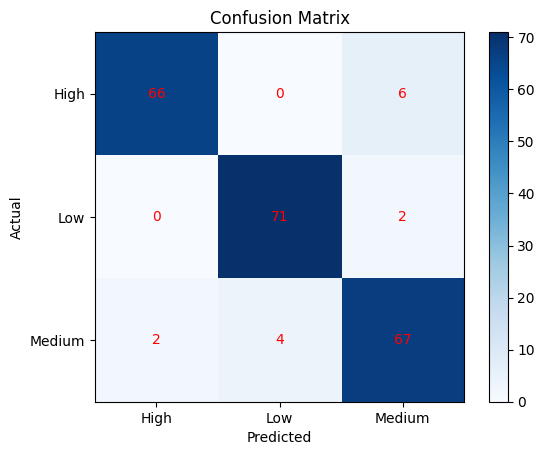

Accuracy: 0.9357798165137615
Precision: 0.9367080410145711
Recall: 0.9357798165137615
F1-score: 0.9358754560589422


In [51]:
# only works because of 3 ground truths
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                                    random_state=42, stratify=y_encoded
)



pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=3))  # adjust k for small data
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

plot_confusion_matrix(y_test, y_pred, le)
display_metric(y_test, y_pred)



In [52]:
print("X_train:", len(X_train))
print("X_test:", len(X_test))


X_train: 868
X_test: 218


### SVM

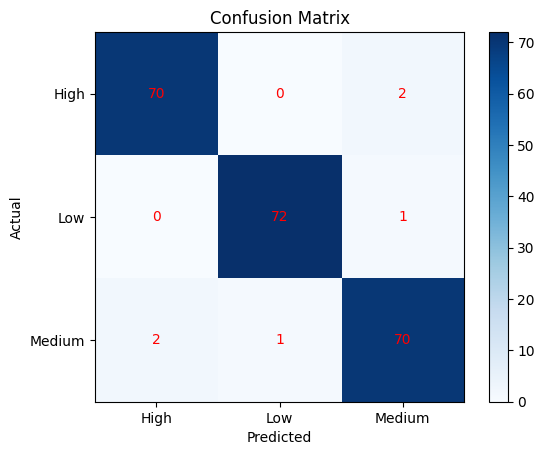

Accuracy: 0.9724770642201835
Precision: 0.9724770642201835
Recall: 0.9724770642201835
F1-score: 0.9724770642201835


In [53]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

#Predictions
y_pred = svm.predict(X_test_scaled)

plot_confusion_matrix(y_test, y_pred, le)
display_metric(y_test, y_pred)


## random forest regression

In [54]:
# Need to use different features columns
feature_columns = ['day', 'car', 'bus', 'cyclist', 'motorbike', 'rigid']
X = df[feature_columns]
y = df['pedestrian']  # Predict pedestrian volume

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and report
y_pred = rf_model.predict(X_test)



In [55]:
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")

preditction = pd.DataFrame({
    'Vehicle': feature_columns,
    'Occurence': rf_model.feature_importances_
}).sort_values('Occurence', ascending=False)

print("\nPredicted Occurence of each vehicle")
print(preditction)

R² Score: 0.8367
RMSE: 103.60
MSE: 10732.92

Predicted Occurence of each vehicle
     Vehicle  Occurence
3    cyclist   0.384457
1        car   0.348819
4  motorbike   0.115237
2        bus   0.102322
0        day   0.031702
5      rigid   0.017462
